# Diagnóstico de haces relativistas mediante radiación de una carga curvada por campo magnético

**Pregunta central:** “¿Puede reconstruirse la energía relativista y estimarse la divergencia angular de un haz de electrones a partir del patrón angular y del contenido espectral de la radiación emitida cuando el haz es curvado por un campo magnético?”

Este notebook reformula el problema como un diagnóstico computacional de haz. La radiación no se estudia solo como una transición descriptiva CRT→sincrotrón, sino como una señal observable que permite inferir parámetros físicos del haz.

## Problema directo e inverso

| Problema | Datos de entrada | Resultado calculado |
|---|---|---|
| Directo | Energía cinética `K` o `gamma`, campo `B_ref` | Trayectoria, patrón angular, FWHM, potencia absoluta y escala espectral. |
| Inverso | Observables sintéticos `Delta theta_obs` y `m_c_obs` | Reconstrucción de `gamma`, energía cinética `K` y divergencia angular del haz. |

El CRT queda como apéndice conceptual: ilustra deflexión por fuerza de Lorentz y emisión visible por impacto en fósforo, no una fuente práctica de radiación sincrotrón medible.


## 1. Preparación y reproducibilidad

Se usan constantes SI y figuras reproducibles en `figures/`. El notebook puede ejecutarse desde su propio directorio o desde la raíz del repositorio; en este segundo caso cambia al directorio del notebook antes de crear las figuras.


In [1]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path("Python/electrodos/Electro2")
if NOTEBOOK_DIR.exists() and (NOTEBOOK_DIR / "electro2.ipynb").exists():
    os.chdir(NOTEBOOK_DIR)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

try:
    from scipy.special import jv
    SCIPY_AVAILABLE = True
except Exception:
    jv = None
    SCIPY_AVAILABLE = False

c = 299_792_458.0
m_e = 9.109_383_7015e-31
e_abs = 1.602_176_634e-19
epsilon0 = 8.854_187_8128e-12
mc2_eV = m_e * c**2 / e_abs

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

rng = np.random.default_rng(20260707)

def savefig(name):
    plt.savefig(FIG_DIR / name, bbox_inches="tight")


def gamma_from_kinetic_energy(K_eV):
    """Factor relativista para energía cinética electrónica en eV."""
    return 1.0 + np.asarray(K_eV, dtype=float) / mc2_eV


def kinetic_energy_from_gamma(gamma):
    """Energía cinética electrónica en eV a partir de gamma."""
    return (np.asarray(gamma, dtype=float) - 1.0) * mc2_eV


def beta_from_gamma(gamma):
    """Velocidad adimensional beta=v/c a partir de gamma."""
    gamma = np.asarray(gamma, dtype=float)
    inside = np.maximum(0.0, 1.0 - 1.0 / gamma**2)
    return np.sqrt(inside)


def orbital_frequency(B_T, gamma):
    """Frecuencia angular orbital SI para v perpendicular a B."""
    return e_abs * B_T / (np.asarray(gamma, dtype=float) * m_e)


def orbit_radius(beta, omega0):
    """Radio de curvatura R=v/omega0."""
    return np.asarray(beta, dtype=float) * c / np.asarray(omega0, dtype=float)


def omega_critical(gamma, beta, omega0):
    """Escala crítica omega_c=(3/2) gamma^3 beta omega0."""
    return 1.5 * np.asarray(gamma, dtype=float)**3 * np.asarray(beta, dtype=float) * np.asarray(omega0, dtype=float)


def absolute_power_si(B_T, gamma, beta):
    """Potencia total radiada por carga relativista curvada por campo magnético uniforme."""
    return e_abs**4 * B_T**2 * np.asarray(gamma, dtype=float)**2 * np.asarray(beta, dtype=float)**2 / (6.0 * np.pi * epsilon0 * m_e**2 * c)


def format_energy(K_eV):
    if K_eV >= 1e9:
        return f"{K_eV/1e9:g} GeV"
    if K_eV >= 1e6:
        return f"{K_eV/1e6:g} MeV"
    return f"{K_eV/1e3:g} keV"

assert gamma_from_kinetic_energy(0) == 1
assert beta_from_gamma(1) == 0


## 2. Marco teórico mínimo

En el régimen no relativista, la radiación de una carga acelerada tiene el patrón dipolar de Larmor:

$$
\frac{dP}{d\Omega}\propto \sin^2\alpha,
$$

donde $\alpha$ es el ángulo entre la dirección de observación y la aceleración, no necesariamente el ángulo respecto de la velocidad. En este notebook se fija $\boldsymbol\beta$ sobre $x$ y $\dot{\boldsymbol\beta}$ sobre $y$; por lo tanto, en el corte orbital donde $\theta$ se mide desde la velocidad instantánea, la referencia no relativista es

$$
P_{Larmor}(\theta)\propto 1-(\mathbf n\cdot\hat{\mathbf a})^2=\cos^2\theta.
$$

La potencia total contextual es $P=q^2 a^2/(6\pi\epsilon_0 c^3)$ en SI. Esta forma es útil como referencia angular, pero no describe el beaming relativista.

Para una carga relativista, la distribución angular instantánea de Liénard-Wiechert es

$$
\frac{dP}{d\Omega}=\frac{q^2}{16\pi^2\epsilon_0 c}\frac{\left|\mathbf n\times\left[(\mathbf n-\boldsymbol\beta)\times\dot{\boldsymbol\beta}\right]\right|^2}{(1-\mathbf n\cdot\boldsymbol\beta)^5}.
$$

Esta expresión calcula el patrón instantáneo. El espectro sincrotrón completo requiere la teoría armónica con funciones de Bessel; por eso las FFT de este notebook son solo una visualización fenomenológica y no reemplazan el espectro exacto. Las escalas de alta energía usadas más adelante son angulares $\sim 1/\gamma$ y armónicas $m_c\sim\gamma^3$.

Los cálculos numéricos están en SI. Algunas discusiones y referencias clásicas, en particular Milton/Schwinger, pueden presentar fórmulas en unidades gaussianas; las conversiones de unidades no se mezclan en las rutinas numéricas.


In [2]:
def directions_from_angles(theta, phi=0.0):
    theta = np.asarray(theta, dtype=float)
    phi = np.asarray(phi, dtype=float)
    return np.stack([
        np.cos(theta),
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
    ], axis=-1)


def larmor_reference(theta, phi=0.0):
    """Patrón Larmor no relativista respecto de la aceleración, no de la velocidad."""
    n = directions_from_angles(theta, phi)
    a_hat = np.array([0.0, 1.0, 0.0])
    y = 1.0 - np.sum(n * a_hat, axis=-1)**2
    y = np.maximum(y, 0.0)
    peak = np.nanmax(y)
    return y / peak if peak > 0 else y


def angular_power(theta, phi=0.0, gamma=1.0, beta_dot_scale=1.0):
    """Distribución angular instantánea Liénard-Wiechert para beta en x y beta_dot en y."""
    gamma = float(gamma)
    beta = float(beta_from_gamma(gamma))
    n = directions_from_angles(theta, phi)
    beta_vec = np.array([beta, 0.0, 0.0])
    beta_dot = np.array([0.0, beta_dot_scale, 0.0])
    cross_inner = np.cross(n - beta_vec, beta_dot)
    numerator = np.sum(np.cross(n, cross_inner)**2, axis=-1)
    denom = np.maximum(1e-300, 1.0 - np.sum(n * beta_vec, axis=-1))**5
    prefactor = e_abs**2 / (16.0 * np.pi**2 * epsilon0 * c)
    return prefactor * numerator / denom


def normalized_angular_power(theta, phi=0.0, gamma=1.0):
    values = angular_power(theta, phi=phi, gamma=gamma, beta_dot_scale=1.0)
    peak = np.nanmax(values)
    return values / peak if peak > 0 else values


def adaptive_fwhm(gamma, theta_max=None, n_points=5001):
    """FWHM angular del lóbulo delantero alrededor de theta=0 usando refinamiento local."""
    gamma = float(gamma)
    if theta_max is None:
        theta_max = min(np.pi, max(0.08, 12.0 / gamma))
    theta = np.linspace(-theta_max, theta_max, n_points)
    y = normalized_angular_power(np.abs(theta), gamma=gamma)
    y = y / np.max(y)
    center = int(np.argmax(y))
    half = 0.5

    def crossing(side):
        if side == "left":
            segment = np.where(y[:center] <= half)[0]
            if len(segment) == 0:
                return theta[0]
            i0 = segment[-1]
            i1 = i0 + 1
        else:
            segment = np.where(y[center:] <= half)[0]
            if len(segment) == 0:
                return theta[-1]
            i1 = center + segment[0]
            i0 = i1 - 1
        x0, x1 = theta[i0], theta[i1]
        y0, y1 = y[i0], y[i1]
        if y1 == y0:
            return x1
        return x0 + (half - y0) * (x1 - x0) / (y1 - y0)

    return crossing("right") - crossing("left")

assert adaptive_fwhm(80) < adaptive_fwhm(20) * 1.1


## 3. Problema directo: cinemática y trayectoria

Se evalúan cinco energías representativas con un campo de referencia fijo `B_ref`. La relación usada es

$$\gamma=1+\frac{K}{m_ec^2},\qquad \beta=\sqrt{1-\frac{1}{\gamma^2}},\qquad \omega_0=\frac{eB}{\gamma m_e},\qquad R=\frac{\beta c}{\omega_0}.$$


B_ref = 0.01 T
K        gamma       beta       omega0 [rad/s]     R [m]        m_c=gamma^3      omega_c [rad/s]
 20 keV     1.0391   0.271866       1.6926e+09  4.8153e-02      1.1221e+00       7.7449e+08
100 keV     1.1957   0.548221       1.4710e+09  1.1173e-01      1.7095e+00       2.0678e+09
  1 MeV     2.9570   0.941079       5.9481e+08  4.7432e-01      2.5854e+01       2.1708e+10
100 MeV   196.6951   0.999987       8.9419e+06  3.3526e+01      7.6099e+06       1.0207e+14
  1 GeV  1957.9512   1.000000       8.9830e+05  3.3373e+02      7.5059e+09       1.0114e+16


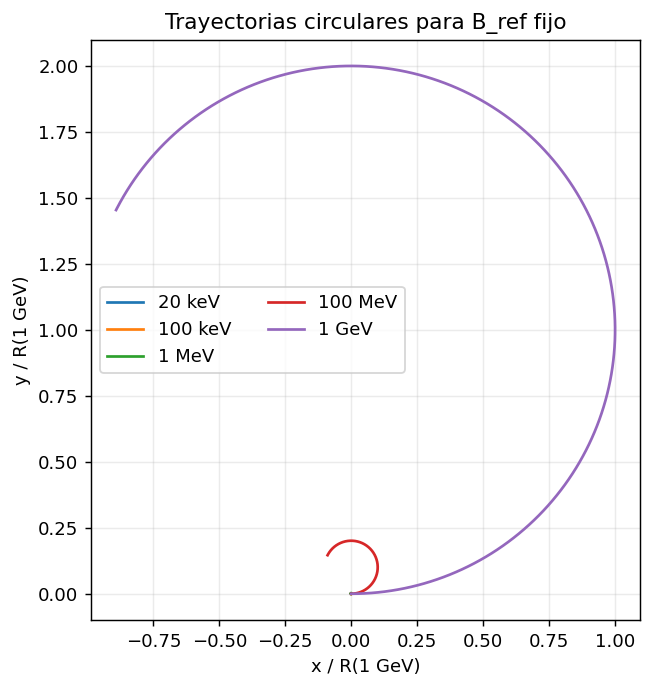

In [3]:
energies_eV = np.array([20e3, 100e3, 1e6, 100e6, 1e9])
energy_labels = [format_energy(K) for K in energies_eV]
B_ref = 0.01

gammas_E = gamma_from_kinetic_energy(energies_eV)
betas_E = beta_from_gamma(gammas_E)
omega0_E = orbital_frequency(B_ref, gammas_E)
radii_E = orbit_radius(betas_E, omega0_E)
mc_E = gammas_E**3
omega_c_E = omega_critical(gammas_E, betas_E, omega0_E)

print(f"B_ref = {B_ref:g} T")
print("K        gamma       beta       omega0 [rad/s]     R [m]        m_c=gamma^3      omega_c [rad/s]")
for row in zip(energy_labels, gammas_E, betas_E, omega0_E, radii_E, mc_E, omega_c_E):
    print(f"{row[0]:>7} {row[1]:10.4f} {row[2]:10.6f} {row[3]:16.4e} {row[4]:11.4e} {row[5]:15.4e} {row[6]:16.4e}")

fig, ax = plt.subplots(figsize=(7.2, 5.8))
phase = np.linspace(0, 1.35*np.pi, 500)
for label, R in zip(energy_labels, radii_E):
    x = R * np.sin(phase)
    y = R * (1 - np.cos(phase))
    scale = radii_E[-1]
    ax.plot(x / scale, y / scale, label=label)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x / R(1 GeV)")
ax.set_ylabel("y / R(1 GeV)")
ax.set_title("Trayectorias circulares para B_ref fijo")
ax.legend(ncol=2)
savefig("trajectory_direct_problem.png")
plt.show()


## 4. Problema directo: patrón angular

La comparación no relativista debe hacerse contra el patrón de Larmor medido desde la aceleración. Como aquí $\boldsymbol\beta\parallel\hat{x}$ y $\dot{\boldsymbol\beta}\parallel\hat{y}$, el corte orbital parametrizado por $\theta$ desde la velocidad usa

$$
P_{Larmor}\propto 1-(\mathbf n\cdot\hat{\mathbf a})^2,
$$

que en este corte coincide con $\cos^2\theta$. Esto evita la confusión de graficar $\sin^2\theta$ respecto de la velocidad. En las gráficas se normaliza cada curva por su máximo para comparar forma, no potencia absoluta.


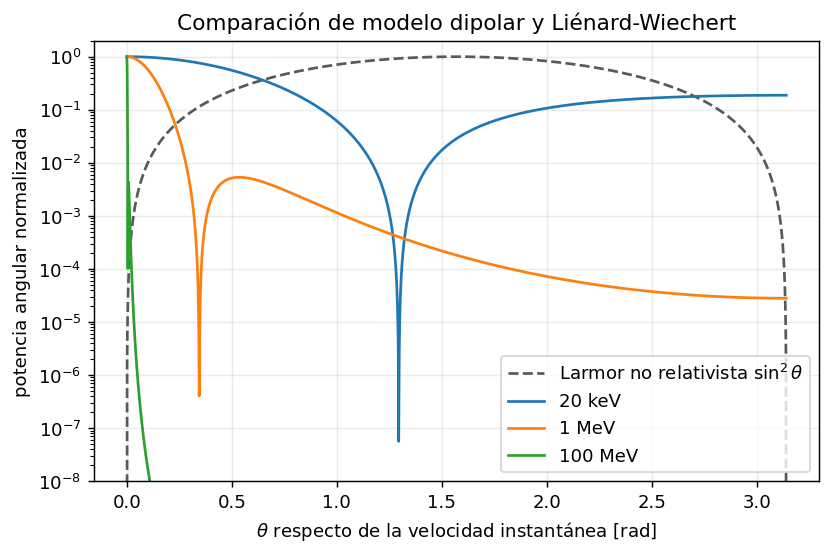

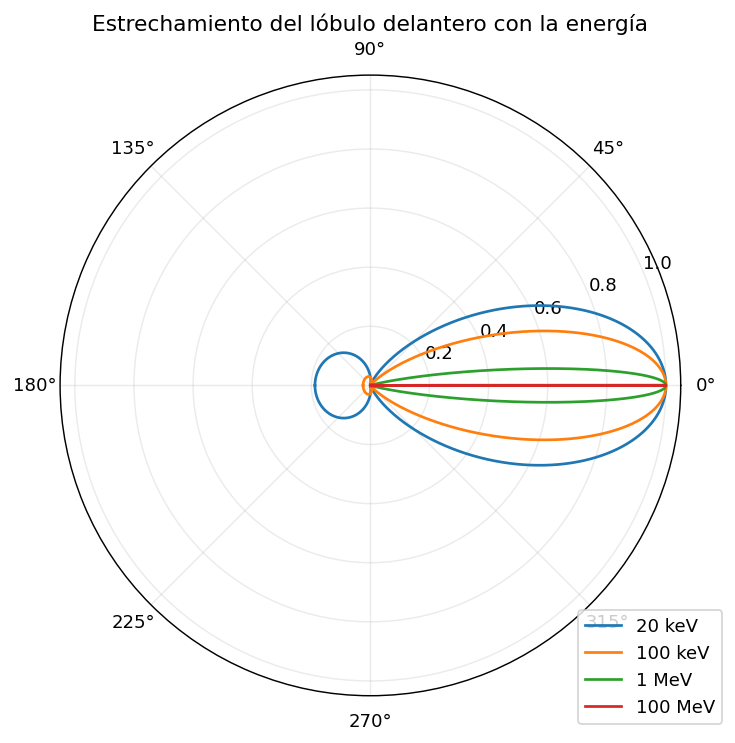

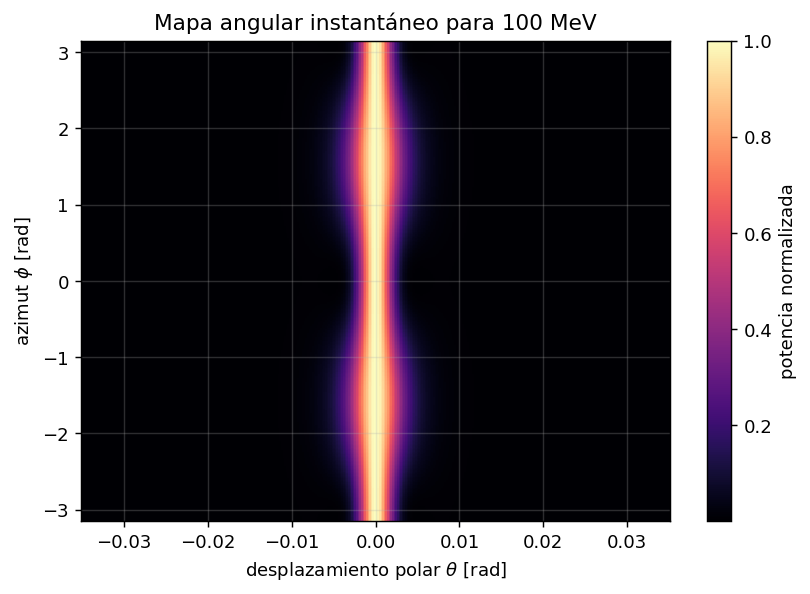

In [4]:
theta = np.linspace(0, np.pi, 2400)
larmor = larmor_reference(theta)

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(theta, larmor, "--", color="0.35", label="Larmor no relativista 1-(n·a_hat)^2")
for K, label in zip([20e3, 1e6, 100e6], ["20 keV", "1 MeV", "100 MeV"]):
    g = gamma_from_kinetic_energy(K)
    ax.plot(theta, normalized_angular_power(theta, gamma=g), label=label)
ax.set_yscale("log")
ax.set_ylim(1e-8, 2)
ax.set_xlabel(r"$\theta$ respecto de la velocidad instantánea [rad]")
ax.set_ylabel("potencia angular normalizada")
ax.set_title("Comparación de Larmor y Liénard-Wiechert")
ax.legend()
savefig("angular_model_comparison.png")
plt.show()

fig = plt.figure(figsize=(7.0, 6.2))
ax = fig.add_subplot(111, projection="polar")
for K, label in zip(energies_eV[:-1], energy_labels[:-1]):
    g = gamma_from_kinetic_energy(K)
    th = np.linspace(-np.pi, np.pi, 4000)
    ax.plot(th, normalized_angular_power(np.abs(th), gamma=g), label=label)
ax.set_title("Estrechamiento del lóbulo delantero con la energía")
ax.set_rlim(0, 1.05)
ax.legend(loc="lower left", bbox_to_anchor=(0.82, -0.06))
savefig("polar_beaming_energy_comparison.png")
plt.show()

K_heat = 100e6
g_heat = gamma_from_kinetic_energy(K_heat)
th_h = np.linspace(-0.035, 0.035, 360)
ph_h = np.linspace(-np.pi, np.pi, 360)
TH, PH = np.meshgrid(th_h, ph_h)
Z = normalized_angular_power(np.abs(TH), phi=PH, gamma=g_heat)
fig, ax = plt.subplots(figsize=(7.3, 4.8))
im = ax.pcolormesh(th_h, ph_h, Z, shading="auto", cmap="magma")
fig.colorbar(im, ax=ax, label="potencia normalizada")
ax.set_xlabel(r"desplazamiento polar $\theta$ [rad]")
ax.set_ylabel(r"azimut $\phi$ [rad]")
ax.set_title("Mapa angular instantáneo para 100 MeV")
savefig("angular_heatmap_100MeV.png")
plt.show()


## 5. Calibración FWHM del lóbulo delantero

No se usa $\mathrm{FWHM}\sim 2/\gamma$ como predicción. Se mide el ancho con un método adaptativo y luego se calibra empíricamente el coeficiente

$$A_{fit}=\operatorname{mediana}\left(\Delta\theta_{FWHM}\,\gamma\right)_{\gamma>50}.$$

El resultado confirma la escala física $1/\gamma$; la constante de proporcionalidad depende de la definición de ancho, del corte angular y de si se mide lóbulo instantáneo, promedio orbital o convolución instrumental.


A_fit = 0.6352 rad


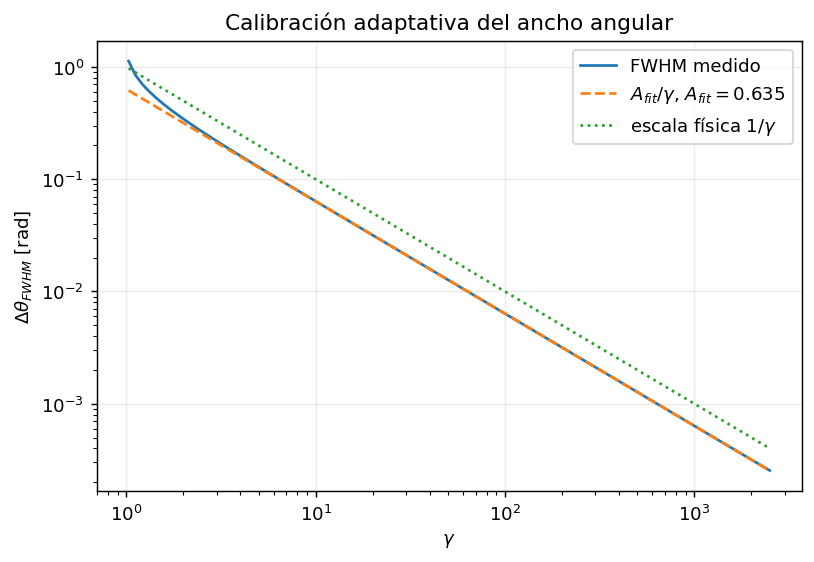

In [5]:
gamma_sweep = np.logspace(np.log10(1.03), np.log10(2500), 95)
width_sweep = np.array([adaptive_fwhm(g, n_points=7001) for g in gamma_sweep])
A_fit = np.median(width_sweep[gamma_sweep > 50] * gamma_sweep[gamma_sweep > 50])
print(f"A_fit = {A_fit:.4f} rad")

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.loglog(gamma_sweep, width_sweep, label="FWHM medido")
ax.loglog(gamma_sweep, A_fit/gamma_sweep, "--", label=rf"$A_{{fit}}/\gamma$, $A_{{fit}}={A_fit:.3f}$")
ax.loglog(gamma_sweep, 1/gamma_sweep, ":", label=r"escala física $1/\gamma$")
ax.set_xlabel(r"$\gamma$")
ax.set_ylabel(r"$\Delta\theta_{FWHM}$ [rad]")
ax.set_title("Calibración adaptativa del ancho angular")
ax.legend()
savefig("fwhm_calibration.png")
plt.show()


## 6. Asimetría adelante/atrás

Para radiación acelerada relativista, la concentración hacia adelante puede resumirse con la razón

$$\frac{P_{forward}}{P_{backward}}=\left(\frac{1+\beta}{1-\beta}\right)^3.$$


K        beta          P_forward/P_backward
 20 keV   0.27186591               5.3295e+00
100 keV   0.54822086               4.0246e+01
  1 MeV   0.94107923               3.5754e+04
100 MeV   0.99998708               3.7062e+15
  1 GeV   0.99999987               3.6057e+21


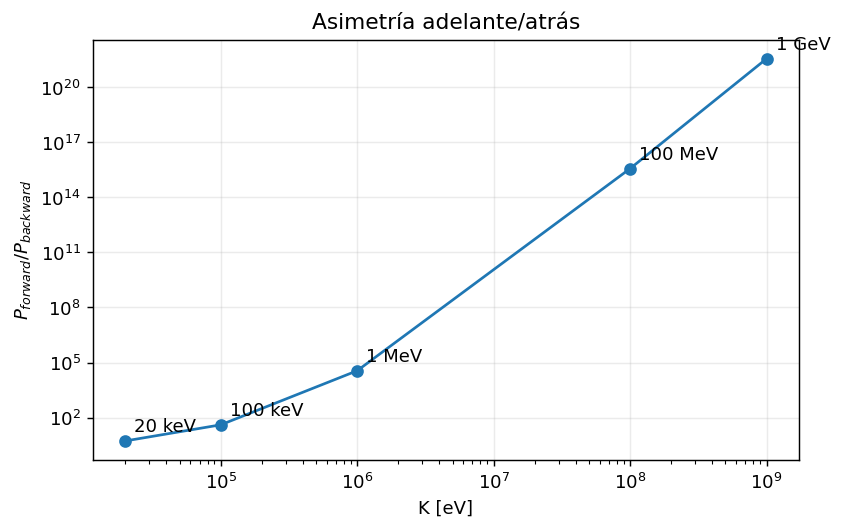

In [6]:
asymmetry = ((1 + betas_E) / (1 - betas_E))**3
print("K        beta          P_forward/P_backward")
for label, beta, ratio in zip(energy_labels, betas_E, asymmetry):
    print(f"{label:>7} {beta:12.8f} {ratio:24.4e}")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.semilogy(energies_eV, asymmetry, marker="o")
ax.set_xscale("log")
ax.set_xlabel("K [eV]")
ax.set_ylabel(r"$P_{forward}/P_{backward}$")
ax.set_title("Asimetría adelante/atrás")
for K, label, ratio in zip(energies_eV, energy_labels, asymmetry):
    ax.annotate(label, (K, ratio), textcoords="offset points", xytext=(5, 5))
savefig("forward_backward_asymmetry.png")
plt.show()


## 7. Potencia absoluta en SI

Para un electrón curvado por un campo magnético uniforme se usa

$$P=\frac{e^4B^2\gamma^2\beta^2}{6\pi\epsilon_0m_e^2c}.$$

La emisión en un CRT existe en principio porque las cargas aceleradas irradian, pero es despreciable como fuente sincrotrón: lo visible en el dispositivo real es la energía depositada por impacto en el fósforo de la pantalla.


K        P [W]
 20 keV   1.2666e-19
100 keV   6.8194e-19
  1 MeV   1.2289e-17
100 MeV   6.1400e-14
  1 GeV   6.0841e-12


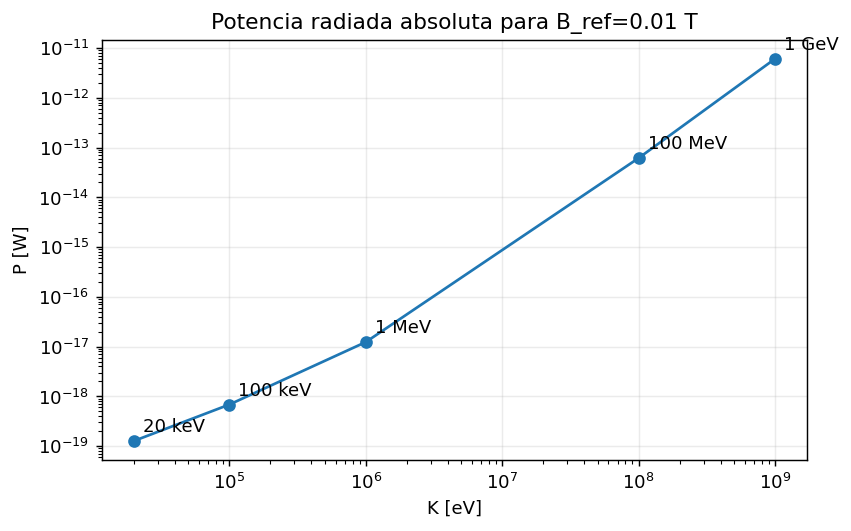

In [7]:
power_E = absolute_power_si(B_ref, gammas_E, betas_E)
print("K        P [W]")
for label, P in zip(energy_labels, power_E):
    print(f"{label:>7} {P:12.4e}")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.loglog(energies_eV, power_E, marker="o")
ax.set_xlabel("K [eV]")
ax.set_ylabel("P [W]")
ax.set_title(f"Potencia radiada absoluta para B_ref={B_ref:g} T")
for K, label, P in zip(energies_eV, energy_labels, power_E):
    ax.annotate(label, (K, P), textcoords="offset points", xytext=(5, 5))
savefig("absolute_power_si.png")
plt.show()


## 8. Escala espectral crítica

Se usa $m_c=\gamma^3$ como escala armónica adimensional y

$$\omega_c=\frac{3}{2}\gamma^3\beta\omega_0.$$

En régimen de baja $\beta$ no conviene sobreinterpretar $m_c$: es una escala de transición hacia el comportamiento sincrotrón, no un conteo exacto de líneas dominantes.


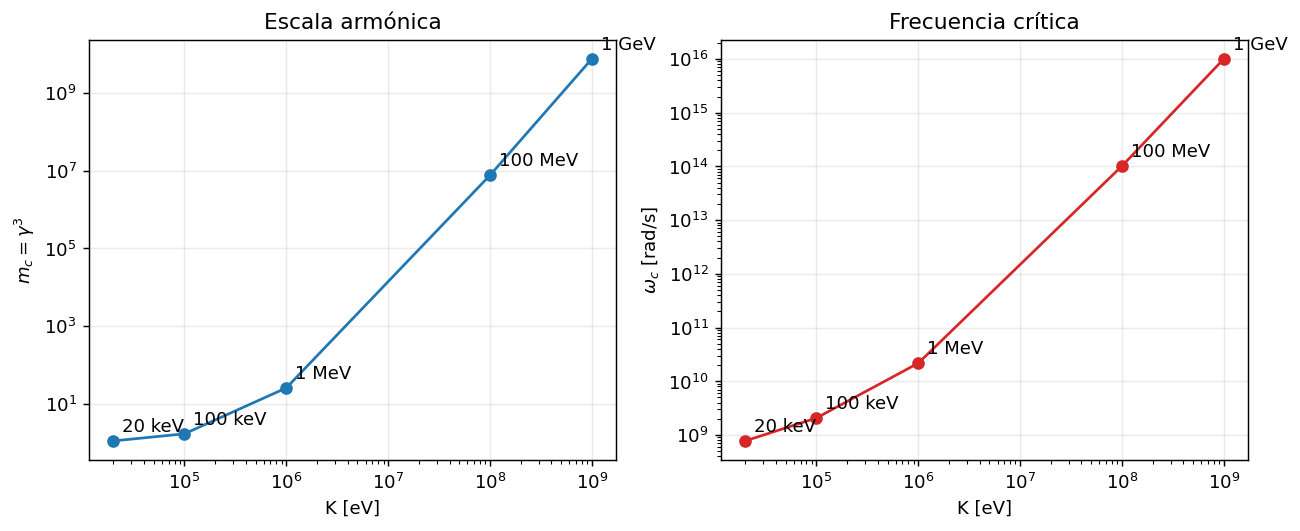

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax1.loglog(energies_eV, mc_E, marker="o")
ax1.set_xlabel("K [eV]")
ax1.set_ylabel(r"$m_c=\gamma^3$")
ax1.set_title("Escala armónica")
ax2.loglog(energies_eV, omega_c_E, marker="o", color="tab:red")
ax2.set_xlabel("K [eV]")
ax2.set_ylabel(r"$\omega_c$ [rad/s]")
ax2.set_title("Frecuencia crítica")
for ax in (ax1, ax2):
    for K, label in zip(energies_eV, energy_labels):
        y = mc_E[list(energies_eV).index(K)] if ax is ax1 else omega_c_E[list(energies_eV).index(K)]
        ax.annotate(label, (K, y), textcoords="offset points", xytext=(5, 5))
savefig("critical_frequency_scale.png")
plt.show()


## 9. FFT cualitativa de armónicos

Esta sección solo visualiza que pulsos temporales más estrechos contienen armónicos más altos. No reemplaza el espectro sincrotrón completo con teoría armónica y funciones de Bessel. Para evitar submuestreo se usan energías moderadas: 20 keV, 100 keV y 1 MeV.


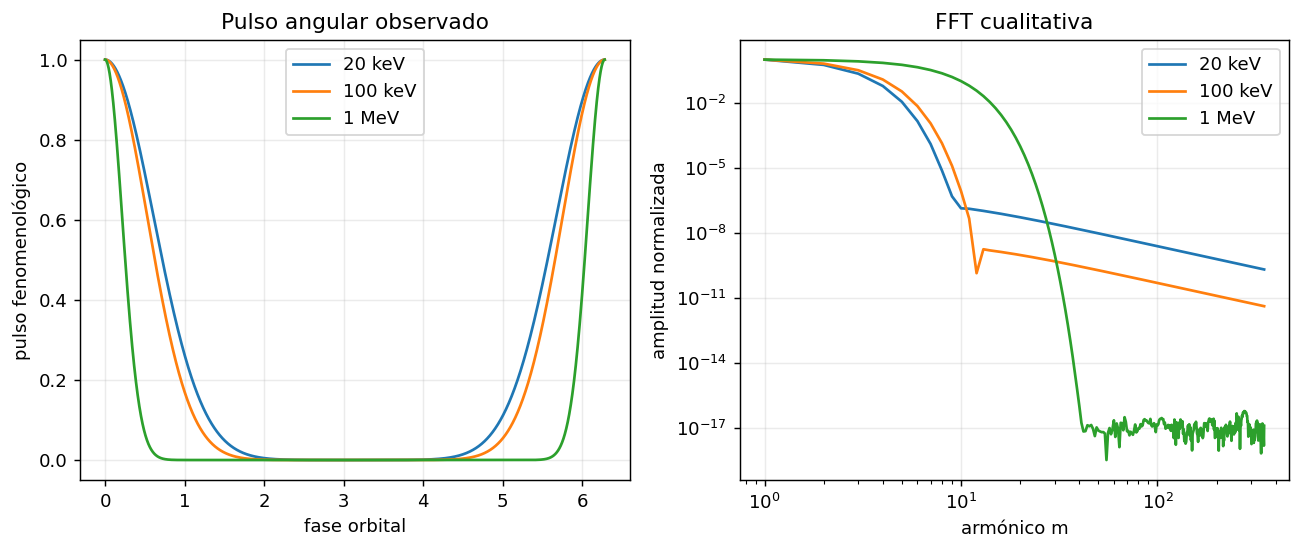

In [9]:
def wrapped_angle(x):
    return (x + np.pi) % (2*np.pi) - np.pi

n = 4096
phase = np.linspace(0, 2*np.pi, n, endpoint=False)
fig, (ax_t, ax_f) = plt.subplots(1, 2, figsize=(12, 4.4))
for K in [20e3, 100e3, 1e6]:
    g = gamma_from_kinetic_energy(K)
    width = max(0.08, A_fit/g)
    pulse = np.exp(-0.5 * (wrapped_angle(phase) / width)**2)
    pulse += np.exp(-0.5 * (wrapped_angle(phase - 2*np.pi) / width)**2)
    pulse /= pulse.max()
    spectrum = np.abs(np.fft.rfft(pulse - pulse.mean()))
    harmonic = np.fft.rfftfreq(n, d=1/n)
    ax_t.plot(phase, pulse, label=format_energy(K))
    ax_f.loglog(harmonic[1:350], spectrum[1:350] / spectrum[1:350].max(), label=format_energy(K))
ax_t.set_xlabel("fase orbital")
ax_t.set_ylabel("pulso fenomenológico")
ax_t.set_title("Pulso angular observado")
ax_t.legend()
ax_f.set_xlabel("armónico m")
ax_f.set_ylabel("amplitud normalizada")
ax_f.set_title("FFT cualitativa")
ax_f.legend()
savefig("fft_qualitative_harmonics.png")
plt.show()


## 10. Sección opcional: armónicos con Bessel

La teoría sincrotrón exacta usa funciones de Bessel. Si `scipy` está disponible, se grafica una combinación armónica ilustrativa para un `gamma` moderado. Si no está disponible, la sección se omite sin interrumpir el notebook.


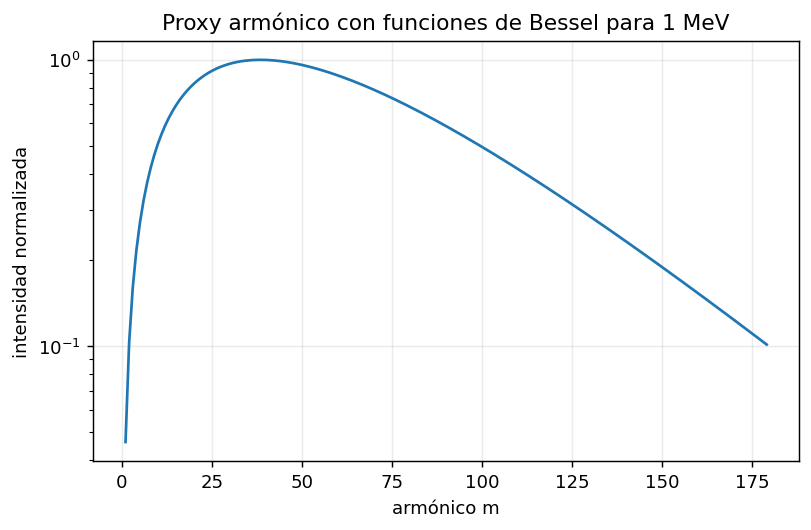

In [10]:
if SCIPY_AVAILABLE:
    gamma_bessel = gamma_from_kinetic_energy(1e6)
    beta_bessel = beta_from_gamma(gamma_bessel)
    m = np.arange(1, 180)
    x = m * beta_bessel
    proxy = m**2 * (jv(m, x)**2 + beta_bessel**2 * jv(np.maximum(m-1, 0), x)**2)
    proxy = np.maximum(proxy, 1e-300)
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    ax.semilogy(m, proxy / proxy.max())
    ax.set_xlabel("armónico m")
    ax.set_ylabel("intensidad normalizada")
    ax.set_title("Proxy armónico con funciones de Bessel para 1 MeV")
    savefig("bessel_optional_harmonics.png")
    plt.show()
else:
    print("scipy no está disponible; se omite la gráfica opcional con funciones de Bessel.")


## 11. Problema inverso: reconstrucción de energía

El observable angular estima `gamma` por beaming, mientras que el contenido espectral lo estima por armónicos. La consistencia entre ambos es una prueba diagnóstica: si discrepan más allá de incertidumbres, el modelo de haz monoenergético y divergencia simple probablemente no alcanza.


K true    gamma true   gamma_width  err_width[%]   gamma_mc   err_mc[%]   K_width[eV]   K_mc[eV]
  1 MeV       2.957        2.747         -7.11      2.924      -1.10   8.9263e+05   9.8338e+05
100 MeV     196.695      183.108         -6.91    189.145      -3.84   9.3057e+07   9.6142e+07
  1 GeV    1957.951     1883.088         -3.82   1921.053      -1.88   9.6174e+08   9.8114e+08


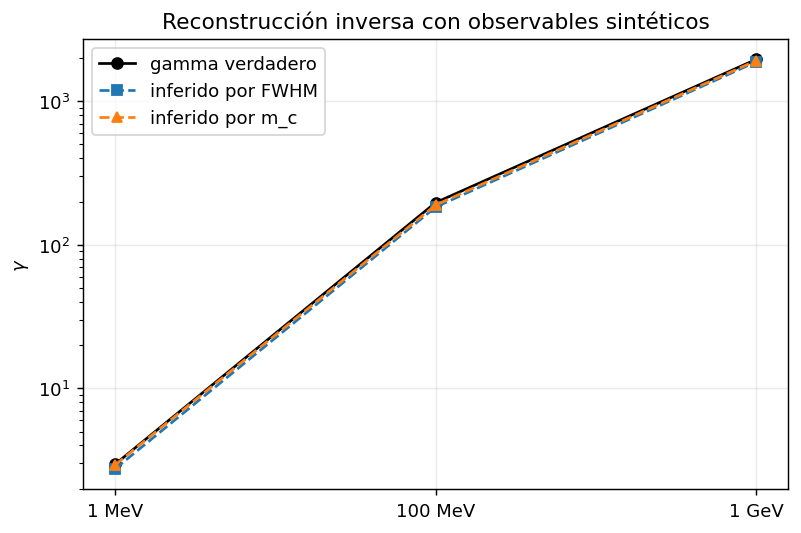

In [11]:
def infer_gamma_from_width(width_obs, A_fit):
    return A_fit / np.asarray(width_obs, dtype=float)


def infer_gamma_from_mc(mc_obs, factor=1.0):
    return (np.asarray(mc_obs, dtype=float) / factor)**(1.0/3.0)

true_K = np.array([1e6, 100e6, 1e9])
true_gamma = gamma_from_kinetic_energy(true_K)
true_width = np.array([adaptive_fwhm(g, n_points=8001) for g in true_gamma])
true_mc = true_gamma**3
width_obs = true_width * (1 + rng.normal(0, 0.05, size=true_width.shape))
mc_obs = true_mc * (1 + rng.normal(0, 0.05, size=true_mc.shape))

gamma_width = infer_gamma_from_width(width_obs, A_fit)
gamma_mc = infer_gamma_from_mc(mc_obs)
K_width = kinetic_energy_from_gamma(gamma_width)
K_mc = kinetic_energy_from_gamma(gamma_mc)
err_width = 100 * (gamma_width - true_gamma) / true_gamma
err_mc = 100 * (gamma_mc - true_gamma) / true_gamma

print("K true    gamma true   gamma_width  err_width[%]   gamma_mc   err_mc[%]   K_width[eV]   K_mc[eV]")
for row in zip(true_K, true_gamma, gamma_width, err_width, gamma_mc, err_mc, K_width, K_mc):
    print(f"{format_energy(row[0]):>7} {row[1]:11.3f} {row[2]:12.3f} {row[3]:13.2f} {row[4]:10.3f} {row[5]:10.2f} {row[6]:12.4e} {row[7]:12.4e}")

fig, ax = plt.subplots(figsize=(7.0, 4.5))
idx = np.arange(len(true_K))
ax.plot(idx, true_gamma, "ko-", label="gamma verdadero")
ax.plot(idx, gamma_width, "s--", label="inferido por FWHM")
ax.plot(idx, gamma_mc, "^--", label="inferido por m_c")
ax.set_xticks(idx, [format_energy(K) for K in true_K])
ax.set_ylabel(r"$\gamma$")
ax.set_yscale("log")
ax.set_title("Reconstrucción inversa con observables sintéticos")
ax.legend()
savefig("inverse_diagnostic_reconstruction.png")
plt.show()


## 12. Divergencia angular del haz

Si `gamma` se conoce por el observable espectral, el ancho radiativo esperado puede escribirse como una desviación equivalente

$$\sigma_{rad}=\frac{A_{fit}/\gamma_{mc}}{2\sqrt{2\ln 2}},$$

cuando `Delta theta_obs` se midió como FWHM. La divergencia angular del haz se estima por desconvolución cuadrática:

$$\sigma_b\approx \sqrt{\max(0,\sigma_{obs}^2-\sigma_{rad}^2)}.$$


sigma_beam true [rad]   FWHM_obs [rad]   sigma_b estimada [rad]
           0.0000e+00       3.2400e-03              1.1074e-04
           2.5420e-03       6.8400e-03              2.5605e-03
           5.0840e-03       1.2480e-02              5.1192e-03


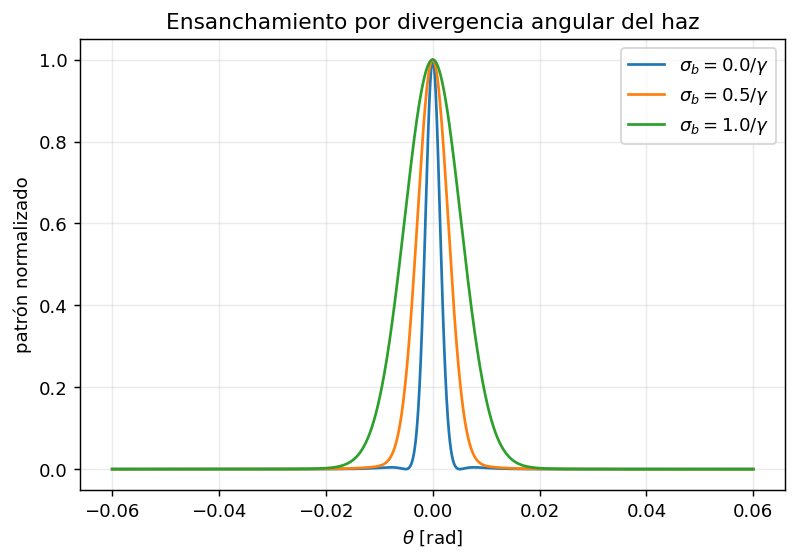

In [12]:
def gaussian_kernel(theta_grid, sigma):
    if sigma <= 0:
        k = np.zeros_like(theta_grid)
        k[len(k)//2] = 1.0
        return k
    k = np.exp(-0.5 * (theta_grid / sigma)**2)
    return k / k.sum()


def broaden_pattern(theta_grid, gamma, sigma_beam):
    base = normalized_angular_power(np.abs(theta_grid), gamma=gamma)
    kernel = gaussian_kernel(theta_grid, sigma_beam)
    broadened = np.convolve(base, kernel, mode="same")
    return broadened / broadened.max()


def fwhm_from_grid(theta_grid, y):
    y = y / y.max()
    center = int(np.argmax(y))
    half = 0.5
    left = np.where(y[:center] <= half)[0]
    right = np.where(y[center:] <= half)[0]
    l = theta_grid[left[-1]] if len(left) else theta_grid[0]
    r = theta_grid[center + right[0]] if len(right) else theta_grid[-1]
    return r - l

gamma_div = gamma_from_kinetic_energy(100e6)
theta_div = np.linspace(-0.06, 0.06, 6001)
cases = [0.0, 0.5/gamma_div, 1.0/gamma_div]
fig, ax = plt.subplots(figsize=(7.0, 4.5))
print("sigma_beam true [rad]   FWHM_obs [rad]   sigma_b estimada [rad]")
for sigma_beam in cases:
    y = broaden_pattern(theta_div, gamma_div, sigma_beam)
    fwhm_obs = fwhm_from_grid(theta_div, y)
    sigma_obs = fwhm_obs / (2*np.sqrt(2*np.log(2)))
    gamma_from_mc = gamma_div
    sigma_rad = (A_fit / gamma_from_mc) / (2*np.sqrt(2*np.log(2)))
    sigma_est = np.sqrt(max(0.0, sigma_obs**2 - sigma_rad**2))
    ax.plot(theta_div, y, label=rf"$\sigma_b={sigma_beam*gamma_div:.1f}/\gamma$")
    print(f"{sigma_beam:21.4e} {fwhm_obs:16.4e} {sigma_est:23.4e}")
ax.set_xlabel(r"$\theta$ [rad]")
ax.set_ylabel("patrón normalizado")
ax.set_title("Ensanchamiento por divergencia angular del haz")
ax.legend()
savefig("beam_divergence_broadening.png")
plt.show()


## 13. Apéndice CRT: deflexión y pantalla

Un CRT acelera electrones y los desvía con campos electromagnéticos. A energías típicas, la radiación electromagnética por curvatura existe formalmente, pero la señal visible del dispositivo es el impacto del haz sobre el fósforo. Por eso el CRT es una analogía de dinámica de haz, no un detector práctico de sincrotrón.


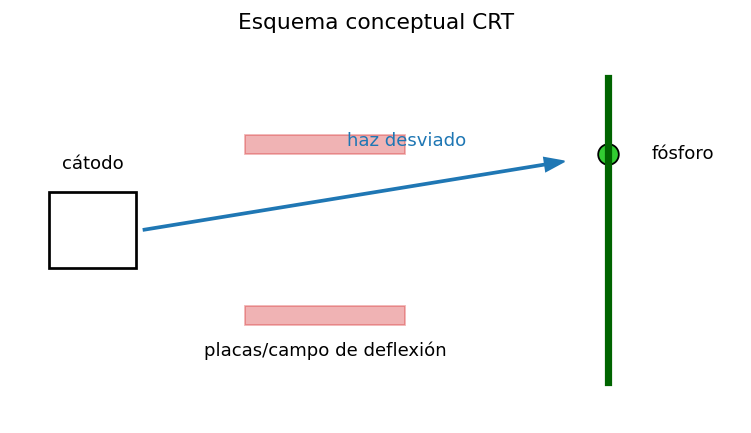

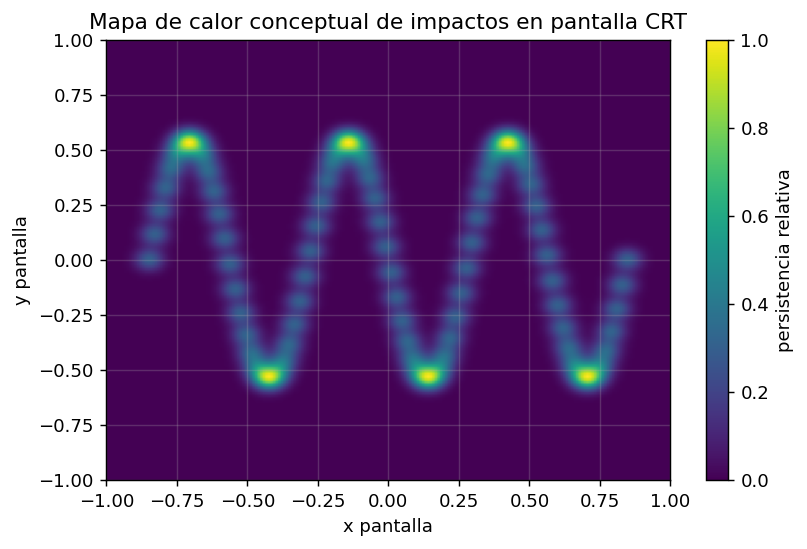

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_xlim(0, 10)
ax.set_ylim(-2.5, 2.5)
ax.axis("off")
ax.add_patch(plt.Rectangle((0.5, -0.5), 1.2, 1.0, fill=False, lw=1.5))
ax.text(1.1, 0.8, "cátodo", ha="center")
ax.arrow(1.8, 0, 5.8, 0.9, width=0.025, head_width=0.18, color="tab:blue", length_includes_head=True)
ax.text(4.6, 1.1, "haz desviado", color="tab:blue")
ax.add_patch(plt.Rectangle((3.2, 1.0), 2.2, 0.25, color="tab:red", alpha=0.35))
ax.add_patch(plt.Rectangle((3.2, -1.25), 2.2, 0.25, color="tab:red", alpha=0.35))
ax.text(4.3, -1.65, "placas/campo de deflexión", ha="center")
ax.plot([8.2, 8.2], [-2, 2], color="darkgreen", lw=4)
ax.scatter([8.2], [1.0], s=130, color="limegreen", edgecolor="black")
ax.text(8.8, 1.0, "fósforo", va="center")
ax.set_title("Esquema conceptual CRT")
savefig("crt_schematic.png")
plt.show()

x = np.linspace(-1, 1, 220)
y = np.linspace(-1, 1, 160)
X, Y = np.meshgrid(x, y)
screen = np.zeros_like(X)
for t in np.linspace(0, 1, 90):
    x0 = -0.85 + 1.7*t
    y0 = 0.55*np.sin(2*np.pi*3*t)
    screen += np.exp(-((X-x0)**2 + (Y-y0)**2)/(2*0.035**2))
screen /= screen.max()
fig, ax = plt.subplots(figsize=(7.0, 4.4))
im = ax.imshow(screen, origin="lower", extent=[-1,1,-1,1], cmap="viridis", aspect="auto")
fig.colorbar(im, ax=ax, label="persistencia relativa")
ax.set_xlabel("x pantalla")
ax.set_ylabel("y pantalla")
ax.set_title("Mapa de calor conceptual de impactos en pantalla CRT")
savefig("crt_screen_heatmap.png")
plt.show()


## 14. Conclusiones

Sí: bajo supuestos controlados puede reconstruirse la energía relativista y estimarse la divergencia angular del haz a partir del patrón angular y del contenido espectral.

La parte angular estima `gamma` porque el lóbulo delantero se estrecha con escala $1/\gamma$. La parte espectral estima `gamma` porque la escala armónica crece como $m_c\sim\gamma^3$. Cuando ambas inferencias concuerdan, el diagnóstico es consistente; cuando no concuerdan, aparecen posibles causas físicas o instrumentales: dispersión de energía, divergencia angular, resolución angular finita, campo no uniforme o uso de un modelo espectral demasiado cualitativo.

**Limitaciones principales:** se usa una distribución angular instantánea de Liénard-Wiechert, el haz se modela con una divergencia gaussiana simple, la FFT es fenomenológica y la sección Bessel es opcional. Un cálculo sincrotrón espectral completo requiere la teoría armónica/Bessel y un modelo temporal/geométrico de observación más detallado.

## Referencias

- Milton, K. A. y Schwinger, J. *Classical Electrodynamics*, 2nd ed., capítulos 34, 35, 38, 41 y 43.
- Jackson, J. D. *Classical Electrodynamics*.
- Griffiths, D. J. *Introduction to Electrodynamics*.
- NIST/CODATA. Valores recomendados de constantes físicas fundamentales usados para $c$, $m_e$, $e$ y $\epsilon_0$.
